<a href="https://colab.research.google.com/github/chamudithamk/ME422-B2-Lab-Group/blob/main/Control/E20_176_A_T_R_Jayawardena_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Twin rotor system

Task 1 - Twin rotor system dynamic model

Following Diagram show the different body frames with twin Rotor

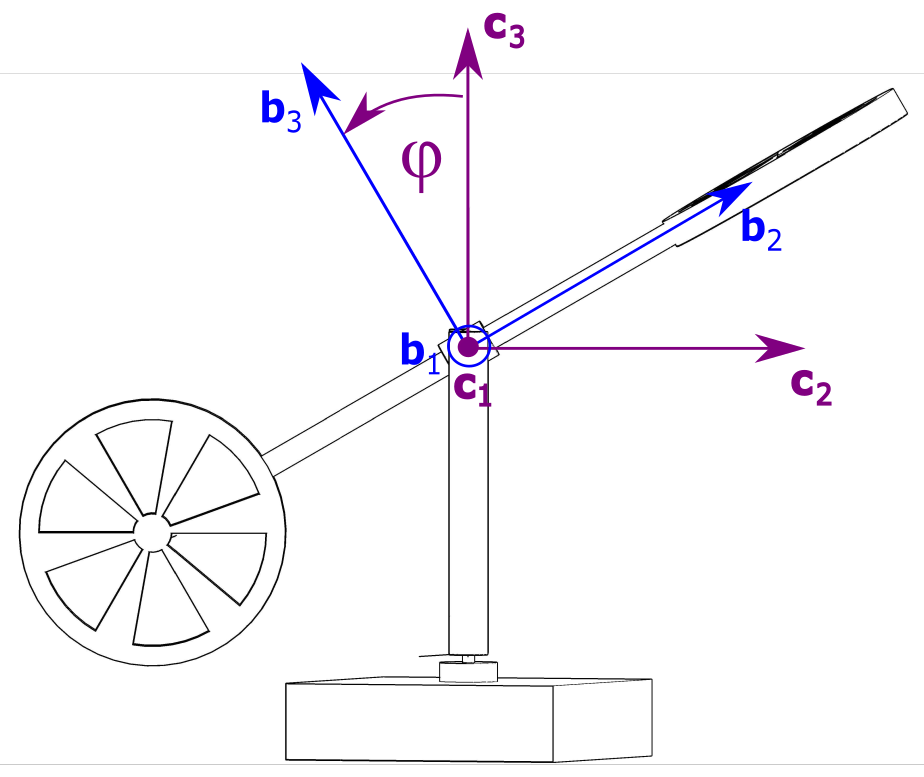

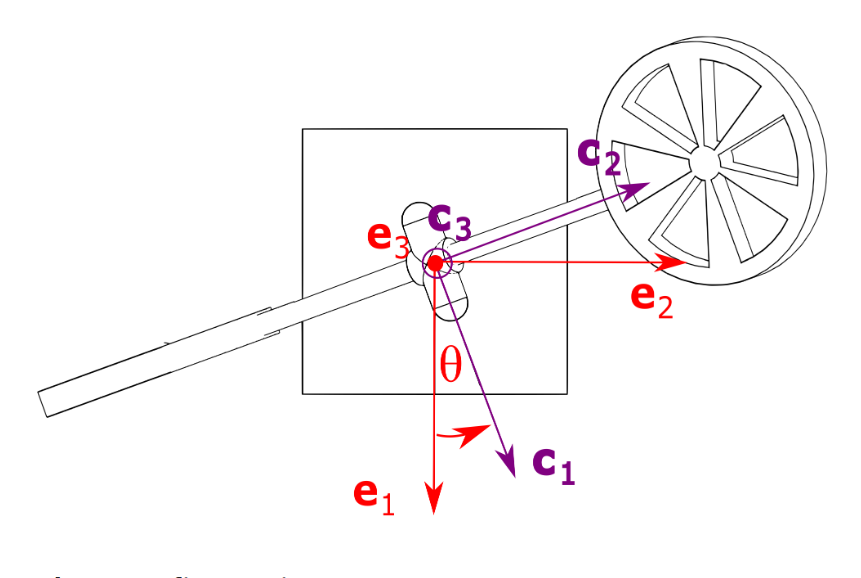

In [ ]:
from IPython.display import Image, display

display(Image('1.png'))
display(Image('2.png'))

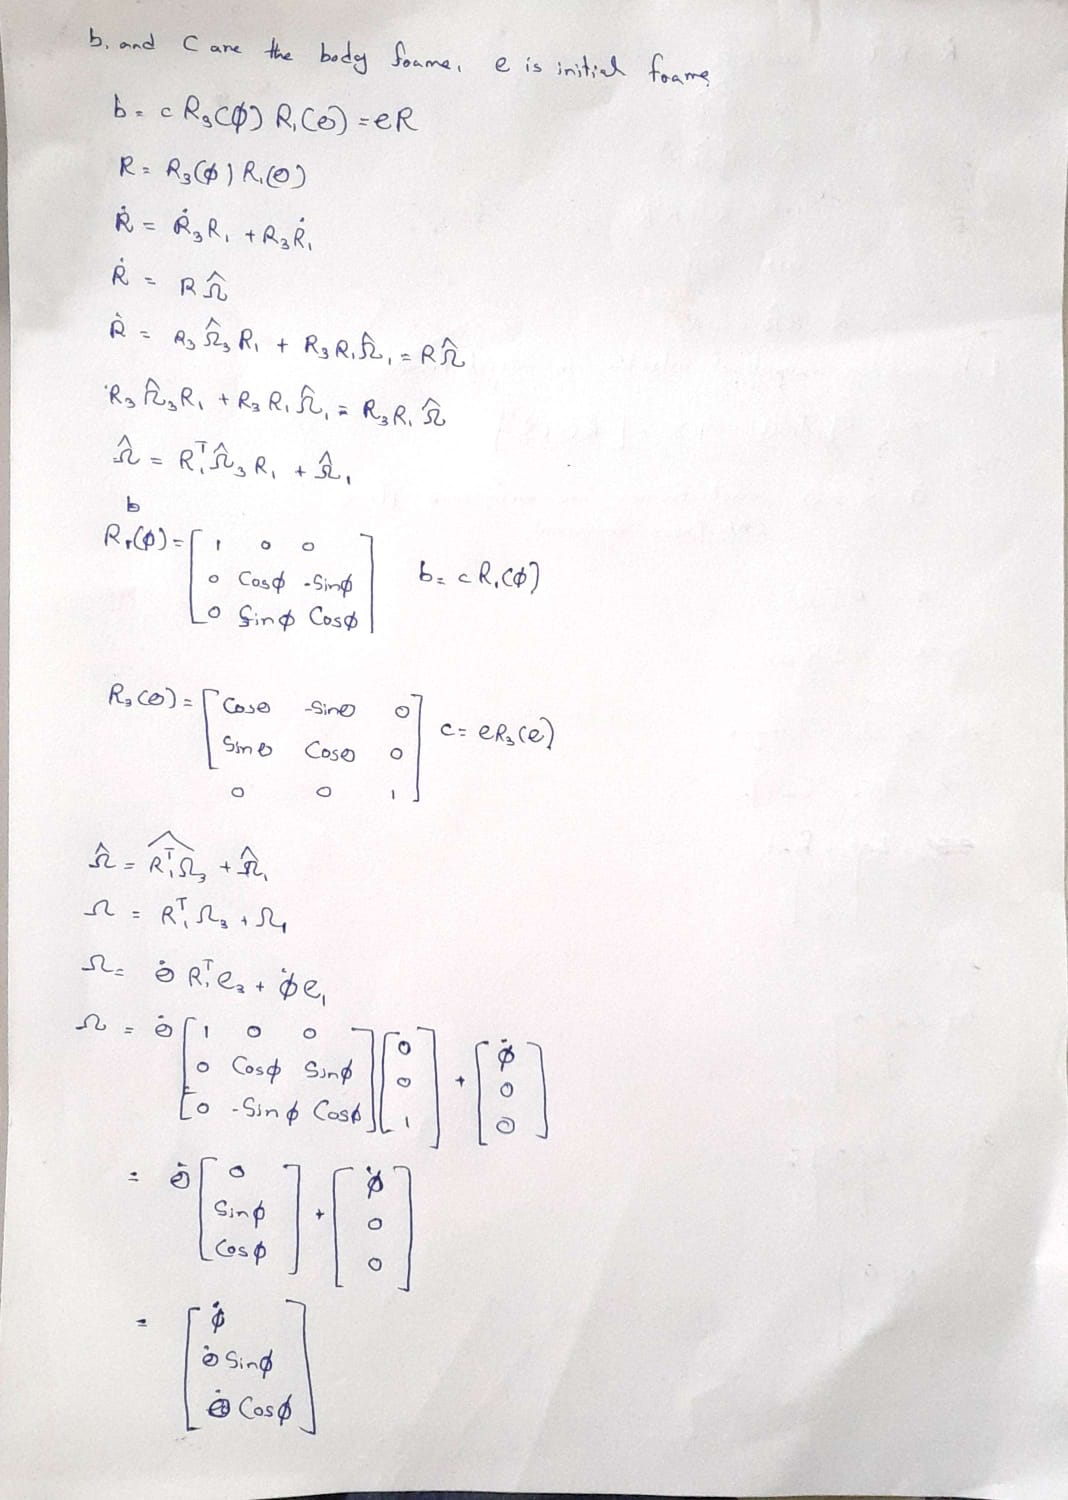

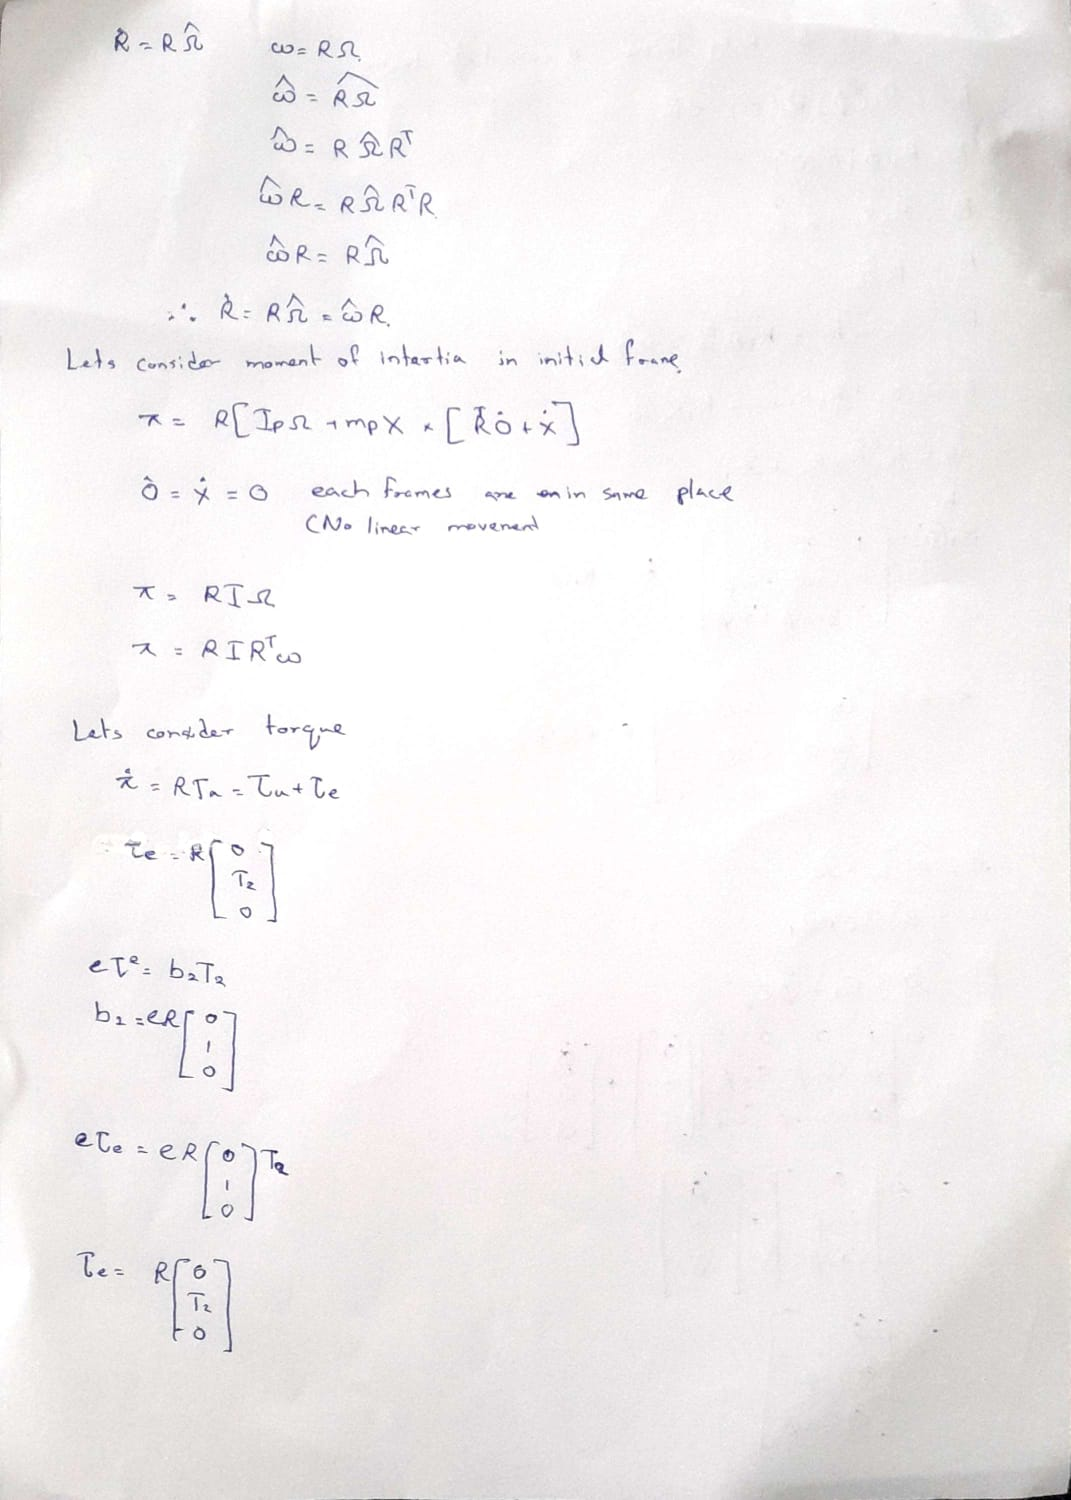

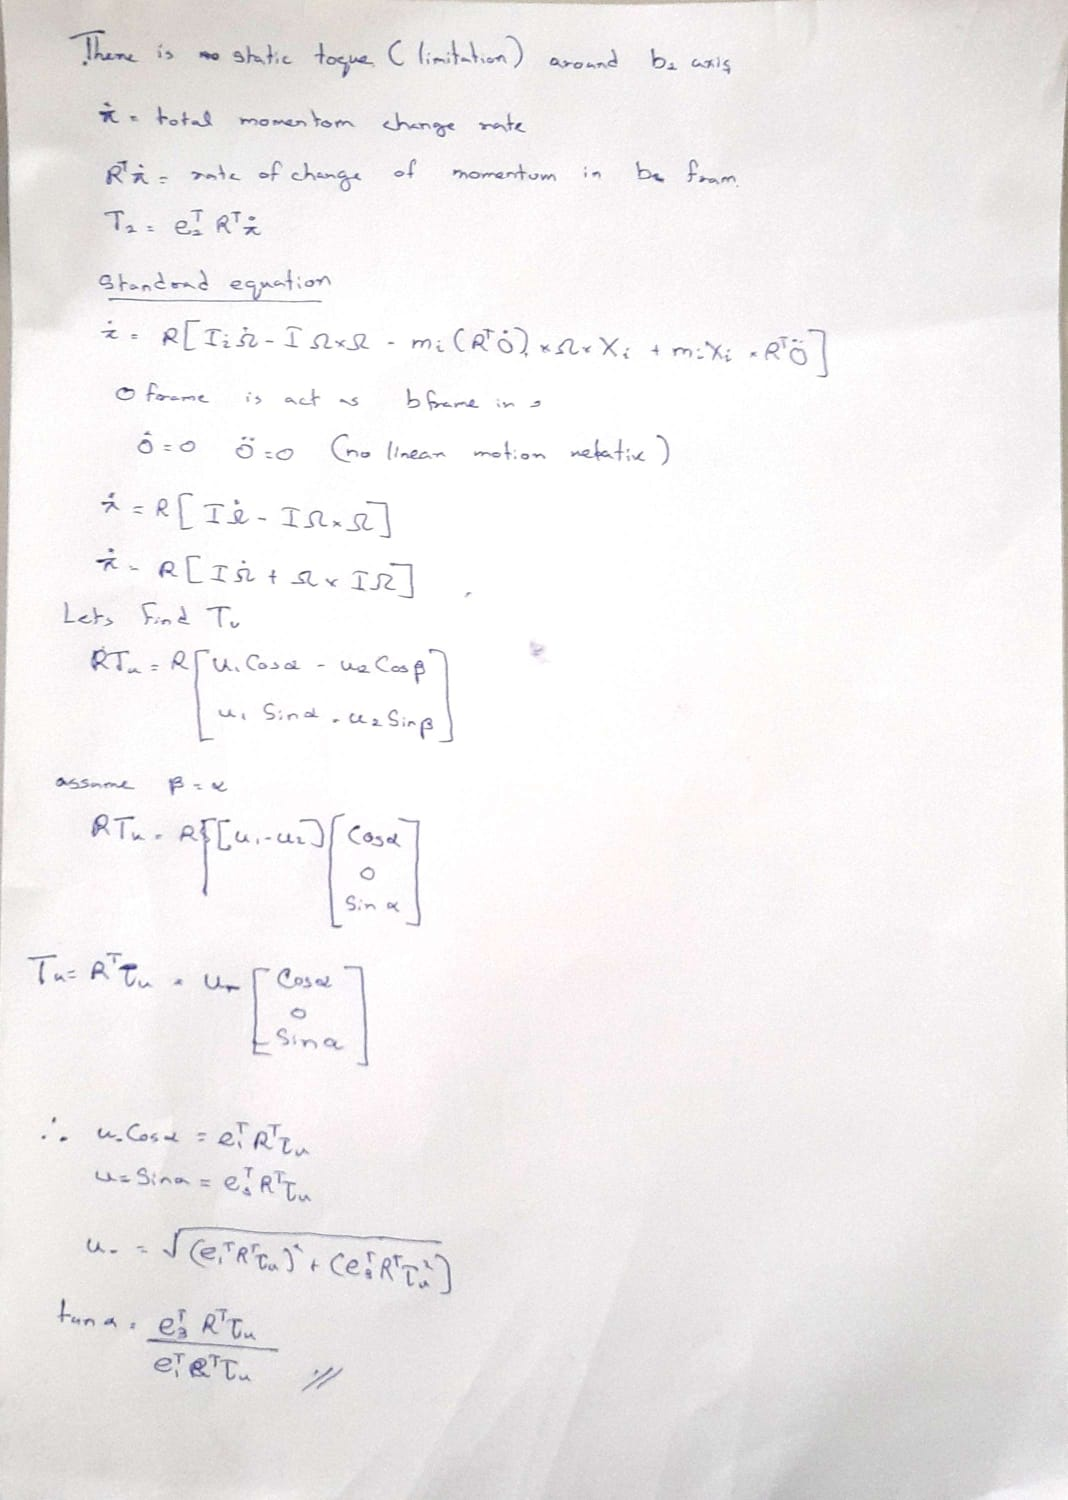

In [ ]:
display(Image('3.jpeg'))
display(Image('4.jpeg'))
display(Image('5.jpeg'))

Task #2: Simulate and animate the motion of the system for various different realistic inputs. For examle a vertical axis spin and a horizontal axis swing up and down motion

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp
from IPython.display import HTML, display

# ==========================================
# 1. CONFIGURATION & PHYSICAL PARAMETERS
# ==========================================
arm_length = 0.4                        # Arm length from center to rotor (m)
J1, J2, J3 = 0.02, 0.08, 0.08          # Principal moments of inertia (kg*m^2)
cant_r1 = 0                             # Rotor 1 tilt angle (0 rad)
cant_r2 = -np.pi / 2                    # Rotor 2 tilt angle (-90 deg)

# ==========================================
# 2. EQUATIONS OF MOTION
# ==========================================
def rotor_system_ode(t, state, thrust1_fn, thrust2_fn):
    yaw, pitch, dyaw, dpitch = state

    # Evaluate rotor thrust inputs at current time
    f1 = thrust1_fn(t)
    f2 = thrust2_fn(t)

    # Compute body-frame torques from rotor thrusts
    torque_yaw   = f1 * np.cos(cant_r1) - f2 * np.cos(cant_r2)
    torque_pitch = f1 * np.sin(cant_r1) - f2 * np.sin(cant_r2)

    # Euler's rotational equations of motion
    ddpitch = (torque_yaw - (J3 - J2) * dyaw**2 * np.sin(pitch) * np.cos(pitch)) / J1

    # Guard against gimbal-lock singularity near ±90°
    if np.abs(np.cos(pitch)) < 1e-4:
        ddyaw = 0.0
    else:
        ddyaw = (torque_pitch - (J2 - J1 - J3) * dyaw * dpitch * np.sin(pitch)) / (J3 * np.cos(pitch))

    return [dyaw, dpitch, ddyaw, ddpitch]

# ==========================================
# 3. 3D ANIMATION BUILDER
# ==========================================
def build_animation(result, time_steps, plot_title):
    yaw_arr   = result.y[0]
    pitch_arr = result.y[1]

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # Axis limits and labels
    bound = 0.6
    ax.set_xlim([-bound, bound])
    ax.set_ylim([-bound, bound])
    ax.set_zlim([-bound, bound])
    ax.set_xlabel('World X (m)')
    ax.set_ylabel('World Y (m)')
    ax.set_zlabel('World Z (m)')
    ax.set_title(plot_title)

    # Static support pillar and dynamic arm/rotor lines
    ax.plot([0, 0], [0, 0], [-bound, 0], 'k-', lw=4)
    arm_plot,   = ax.plot([], [], [], 'k-', lw=5)
    rotor1_plot, = ax.plot([], [], [], 'r-', lw=2)
    rotor2_plot, = ax.plot([], [], [], 'b-', lw=2)

    # --- ROTOR DISK GEOMETRY ---
    ring_angles = np.linspace(0, 2*np.pi, 20)
    disk_radius = 0.1
    ring_cos = disk_radius * np.cos(ring_angles)
    ring_sin = disk_radius * np.sin(ring_angles)

    # Rotor 1 (Red) disk — normal aligned with cant_r1
    r1_x_body = -np.sin(cant_r1) * ring_cos
    r1_y_body =  ring_sin + arm_length
    r1_z_body =  np.cos(cant_r1) * ring_cos
    r1_body_pts = np.array([r1_x_body, r1_y_body, r1_z_body])

    # Rotor 2 (Blue) disk — normal aligned with cant_r2
    r2_x_body = -np.sin(cant_r2) * ring_cos
    r2_y_body =  ring_sin - arm_length
    r2_z_body =  np.cos(cant_r2) * ring_cos
    r2_body_pts = np.array([r2_x_body, r2_y_body, r2_z_body])

    def refresh_frame(frame_idx):
        yaw   = yaw_arr[frame_idx]
        pitch = pitch_arr[frame_idx]

        # Rotation matrix R(yaw, pitch)
        R_mat = np.array([
            [np.cos(yaw), -np.sin(yaw)*np.cos(pitch),  np.sin(yaw)*np.sin(pitch)],
            [np.sin(yaw),  np.cos(yaw)*np.cos(pitch), -np.cos(yaw)*np.sin(pitch)],
            [0,            np.sin(pitch),               np.cos(pitch)]
        ])

        # Rotate arm endpoints into world frame
        tip1 = R_mat @ np.array([0,  arm_length, 0])
        tip2 = R_mat @ np.array([0, -arm_length, 0])
        arm_plot.set_data([tip2[0], tip1[0]], [tip2[1], tip1[1]])
        arm_plot.set_3d_properties([tip2[2], tip1[2]])

        # Rotate Rotor 1 disk
        r1_world = R_mat @ r1_body_pts
        rotor1_plot.set_data(r1_world[0, :], r1_world[1, :])
        rotor1_plot.set_3d_properties(r1_world[2, :])

        # Rotate Rotor 2 disk
        r2_world = R_mat @ r2_body_pts
        rotor2_plot.set_data(r2_world[0, :], r2_world[1, :])
        rotor2_plot.set_3d_properties(r2_world[2, :])

        return arm_plot, rotor1_plot, rotor2_plot

    anim = animation.FuncAnimation(fig, refresh_frame, frames=len(time_steps), interval=40, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

# ==========================================
# 4. SIMULATION SCENARIOS
# ==========================================
sim_span  = (0, 8)
sim_steps = np.linspace(sim_span[0], sim_span[1], 200)
init_state = [0, 0, 0, 0]  # [yaw, pitch, dyaw, dpitch]

# --- SCENARIO A: YAW ROTATION ---
# cant_r2 = -90° means rotor 2 drives pure yaw
def yaw_thrust1(t): return 0.0
def yaw_thrust2(t): return 0.05 if t < 4 else -0.05   # Step yaw command

result_yaw = solve_ivp(rotor_system_ode, sim_span, init_state, t_eval=sim_steps,
                       args=(yaw_thrust1, yaw_thrust2), method='RK45')

print("Rendering Yaw Animation...")
display(build_animation(result_yaw, sim_steps, "Scenario A: Yaw Rotation"))

# --- SCENARIO B: PITCH OSCILLATION ---
# cant_r1 = 0° means rotor 1 drives pure pitch
def pitch_thrust1(t): return 0.02 * np.sin(np.pi * t)  # Sinusoidal pitch command
def pitch_thrust2(t): return 0.0

result_pitch = solve_ivp(rotor_system_ode, sim_span, init_state, t_eval=sim_steps,
                         args=(pitch_thrust1, pitch_thrust2), method='RK45')

print("Rendering Pitch Animation...")
display(build_animation(result_pitch, sim_steps, "Scenario B: Pitch Oscillation"))

I couldn,t save in gitub due to some error the final part of the submission ,Here is the link for that co lab file
https://colab.research.google.com/drive/1MVRqCb7ryzazk32191kGdHShawoRImw8?usp=sharing
